BAO peak at r = 105.8 Mpc/h


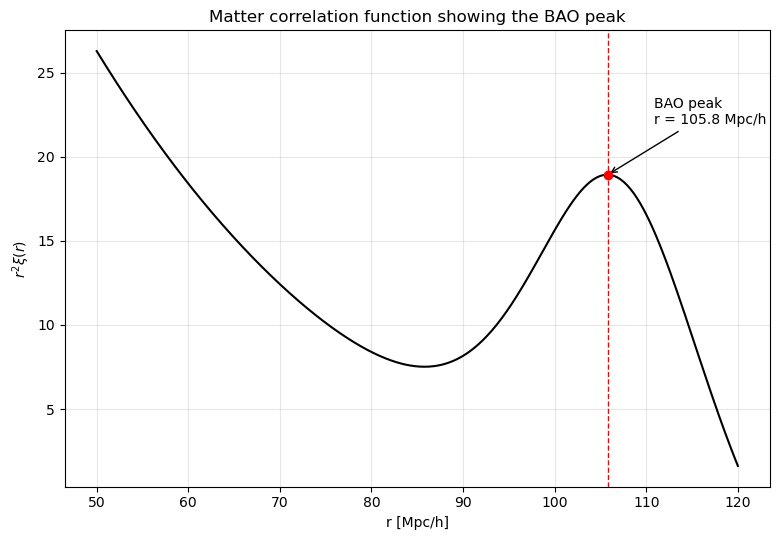

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.integrate import quad
from scipy.signal import argrelextrema
import warnings
warnings.filterwarnings("ignore")  #benign roundoff warning from quad near tiny xi values

#load the tabulated power spectrum
data = np.loadtxt("lcdm_z0 (1).matter_pk")
k_data, P_data = data[:, 0], data[:, 1]   #column 3 is ignored

#cubic spline interpolant in log-log space
#P(k) is close to a power law over most of its range, so splining
#log(P) against log(k) tracks the shape better than splining P against k directly
logk_spline = CubicSpline(np.log(k_data), np.log(P_data))

def P_of_k(k):
    return np.exp(logk_spline(np.log(k)))

kmin = k_data.min()
kmax = k_data.max()   #convergence checked below -- kmax >= ~50 h/Mpc is already sufficient

def xi_of_r(r):
    """
    xi(r) = (1/2 pi^2) * integral dk  k^2 P(k) sin(kr)/(kr)
          = (1/2 pi^2) * integral dk  k P(k) sin(kr) / r
    quad's weight='sin' mode handles the oscillatory sin(kr) factor with
    a specialized oscillatory quadrature rule, rather than needing an
    extremely fine manually-built grid to resolve the oscillations at
    large r -- this is far more efficient and accurate here than a
    plain Simpson/trapezoid sum would be.
    """
    def g(k):
        return k * P_of_k(k) / r
    val, err = quad(g, kmin, kmax, weight="sin", wvar=r, limit=200)
    return val / (2 * np.pi**2)

#evaluating xi(r) over requested range
r_values = np.linspace(50, 120, 400)
xi_values = np.array([xi_of_r(r) for r in r_values])
r2xi = r_values**2 * xi_values

#locating the BAO peak
#The global maximum of r^2 xi(r) over [50,120] is not the BAO peak
#The BAO peak is the local maximum that appears after the local minimum (dip) in r^2 xi(r).
local_min_idx = argrelextrema(r2xi, np.less)[0]
local_max_idx = argrelextrema(r2xi, np.greater)[0]
dip_idx = local_min_idx[0]
peak_idx = local_max_idx[local_max_idx > dip_idx][0]
r_peak, r2xi_peak = r_values[peak_idx], r2xi[peak_idx]
print(f"BAO peak at r = {r_peak:.1f} Mpc/h")

#plotting
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(r_values, r2xi, color="black")
ax.axvline(r_peak, color="red", linestyle="--", linewidth=1)
ax.plot(r_peak, r2xi_peak, "ro", zorder=5)
ax.annotate(f"BAO peak\nr = {r_peak:.1f} Mpc/h",
            xy=(r_peak, r2xi_peak), xytext=(r_peak + 5, r2xi_peak + 3),
            arrowprops=dict(arrowstyle="->"))
ax.set_xlabel(r"r [Mpc/h]")
ax.set_ylabel(r"$r^2 \xi(r)$")
ax.set_title("Matter correlation function showing the BAO peak")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("bao_peak.png", dpi=150)
plt.show()